<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Advanced_ggplot2_Faculty_Salary_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Advanced ggplot2: Faculty Salary Analysis (Practical-i)**

### **নোটবুক পরিচিতি (Metadata)**

* **Aim:** আর (R) এবং `ggplot2` ব্যবহার করে জটিল ডাটাসেট থেকে ইনসাইট বের করা এবং গ্রাফকে পাবলিকেশন-কোয়ালিটি লেভেলে কাস্টমাইজ করা।
* **Dataset:** `car` প্যাকেজের `Salaries` ডেটাসেট (যুক্তরাষ্ট্রের প্রফেসরদের ৯ মাসের বেতন সংক্রান্ত তথ্য)।
* **Key Learnings:** `geom_jitter()` এর ব্যবহার, কাস্টম কালার স্কেল, এক্সিস টিক মার্ক পরিবর্তন এবং প্লটের ভেতরে লেজেন্ড পজিশনিং।

### **১. এনভায়রনমেন্ট সেটআপ এবং ডেটা ওভারভিউ**

শুরুতেই আমরা প্রয়োজনীয় প্যাকেজ লোড করব এবং ডেটা দেখে নেব।

In [ ]:
# প্রয়োজনীয় প্যাকেজ ইন্সটল এবং লোড করা
# install.packages("car")
library(car)
library(tidyverse)

In [ ]:
# ডেটাসেটের প্রথম কয়েকটি রো দেখা
# View(Salaries)
head((Salaries), 8)

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
,<fct>,<fct>,<int>,<int>,<fct>,<int>
1,Prof,B,19,18,Male,139750
2,Prof,B,20,16,Male,173200
3,AsstProf,B,4,3,Male,79750
4,Prof,B,45,39,Male,115000
5,Prof,B,40,41,Male,141500
6,AssocProf,B,6,6,Male,97000
7,Prof,B,30,23,Male,175000
8,Prof,B,45,45,Male,147765


### **২. বেসিক স্ক্যাটার প্লট (Basic Scatter Plot)**

পিএইচডি করার পর কত বছর অতিবাহিত হয়েছে (`yrs.since.phd`) তার সাথে বেতনের (`salary`) সম্পর্ক দেখা যাক।

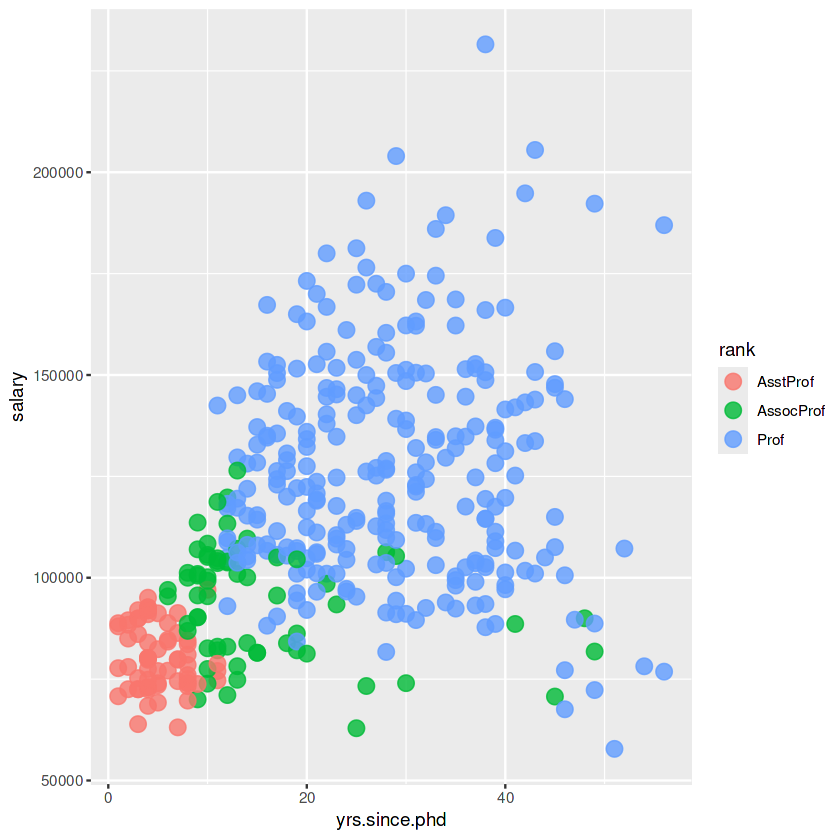

In [ ]:
# ধাপ ১: সাধারণ স্ক্যাটার প্লট
Salaries %>%
  ggplot(aes(yrs.since.phd,
             salary,
             color = rank)) +
  geom_point(size=4, alpha=0.8)

**পর্যবেক্ষণ:** এখানে আমরা দেখতে পাচ্ছি প্রফেশনাল র‍্যাঙ্ক অনুযায়ী বেতন কীভাবে পরিবর্তিত হয়। কিন্তু অনেক ডেটা পয়েন্ট একে অপরের ওপর উপচে পড়ছে (Overlapping)।

### **৩. কাস্টমাইজেশন ও ট্রেন্ড লাইন (Jitter & Smooth)**

ডেটার ওভারল্যাপিং কমাতে আমরা `geom_jitter` ব্যবহার করব এবং একটি রিগ্রেশন লাইন যোগ করব।

`geom_smooth()` using formula = 'y ~ x'


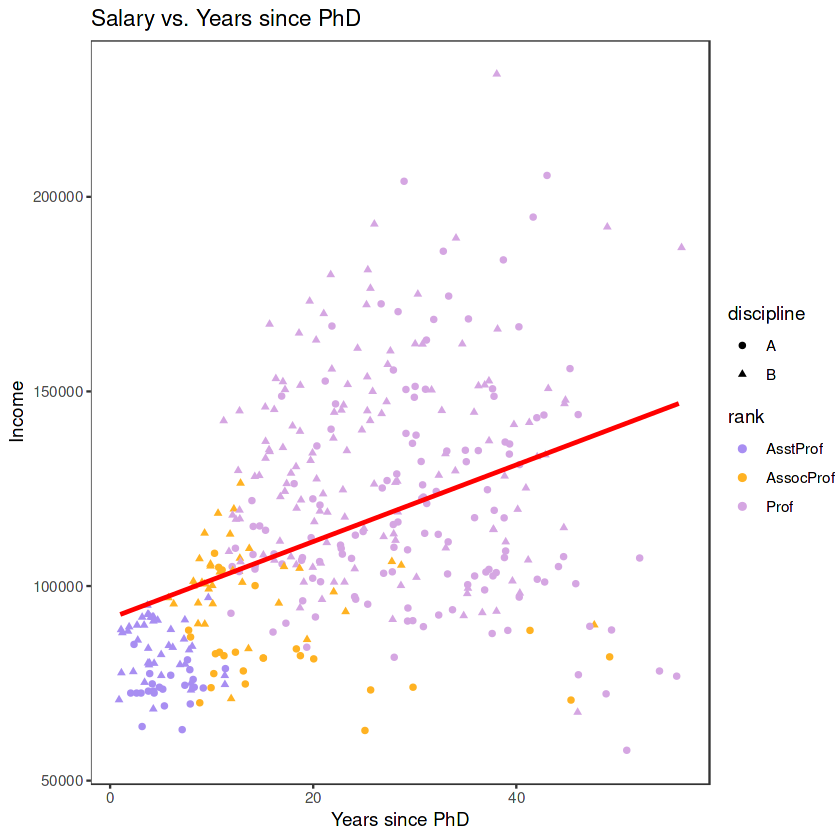

In [ ]:
# ধাপ ২: অ্যাডভান্সড কাস্টমাইজেশন
Salaries %>%
  ggplot(aes(yrs.since.phd, salary)) +
  # geom_jitter ডেটাকে কিছুটা ছড়িয়ে দেয় যাতে ওভারল্যাপিং কম হয়
  geom_jitter(aes(color = rank,
                  shape = discipline)) +
  # রিগ্রেশন লাইন যোগ করা
  geom_smooth(method = lm,
              se = FALSE,
              color = "red") +
  # নিজের পছন্দমতো হেক্স কোড দিয়ে রঙ সেট করা
  scale_color_manual(values = c(
    "AsstProf" = "#A88EF2",
    "AssocProf" = "#FFB222",
    "Prof"     = "#D5A6E2"
  )) +
  theme_test() +
  labs(
    title = "Salary vs. Years since PhD",
    x = "Years since PhD",
    y = "Income",
    Color = "Position",
    Shape = "Research Area"
  )


`geom_smooth()` using formula = 'y ~ x'


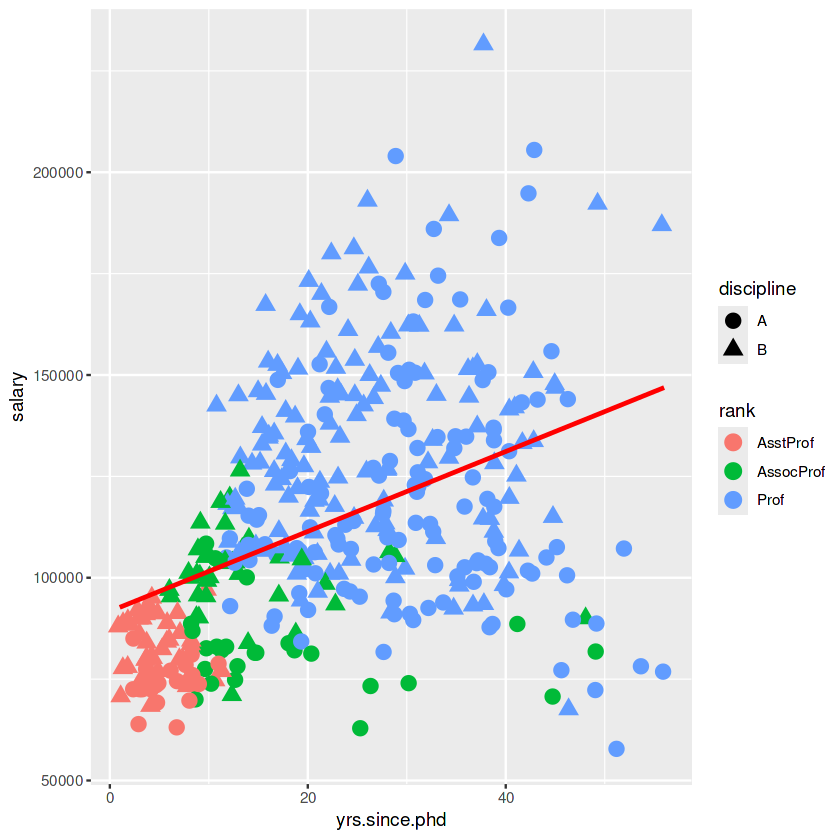

In [ ]:
# ধাপ ৩ঃ অ্যাডভান্সড কাস্টমাইজেশন
Salaries %>%
  ggplot(aes(yrs.since.phd, salary)) +
  # geom_jitter ডেটাকে কিছুটা ছড়িয়ে দেয় যাতে ওভারল্যাপিং কম হয়
  geom_jitter(aes(color = rank,
                  shape = discipline), size=4) +
  # রিগ্রেশন লাইন যোগ করা
  geom_smooth(method = lm,
              se = FALSE,
              color = "red")

`geom_smooth()` using formula = 'y ~ x'


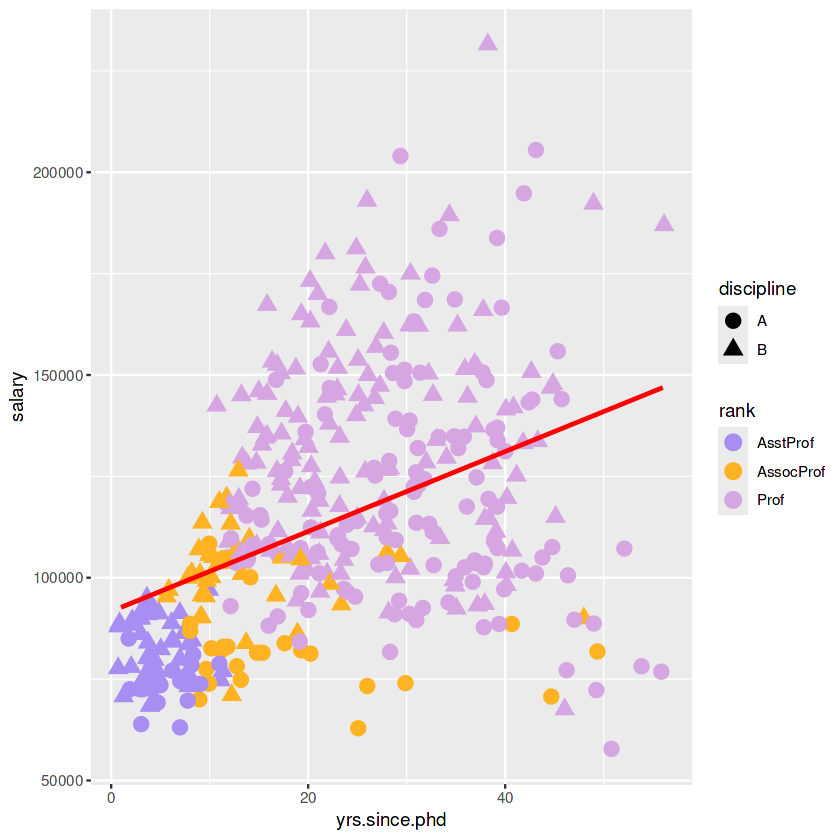

In [ ]:
# ধাপ ৪ঃ অ্যাডভান্সড কাস্টমাইজেশন
Salaries %>%
  ggplot(aes(yrs.since.phd, salary)) +
  # geom_jitter ডেটাকে কিছুটা ছড়িয়ে দেয় যাতে ওভারল্যাপিং কম হয়
  geom_jitter(aes(color = rank,
                  shape = discipline), size=4) +
  # রিগ্রেশন লাইন যোগ করা
  geom_smooth(method = lm,
              se = FALSE,
              color = "red") +
  # নিজের পছন্দমতো হেক্স কোড দিয়ে রঙ সেট করা
  scale_color_manual(values = c(
    "AsstProf" = "#A88EF2",
    "AssocProf" = "#FFB222",
    "Prof"     = "#D5A6E2"
  ))

`geom_smooth()` using formula = 'y ~ x'


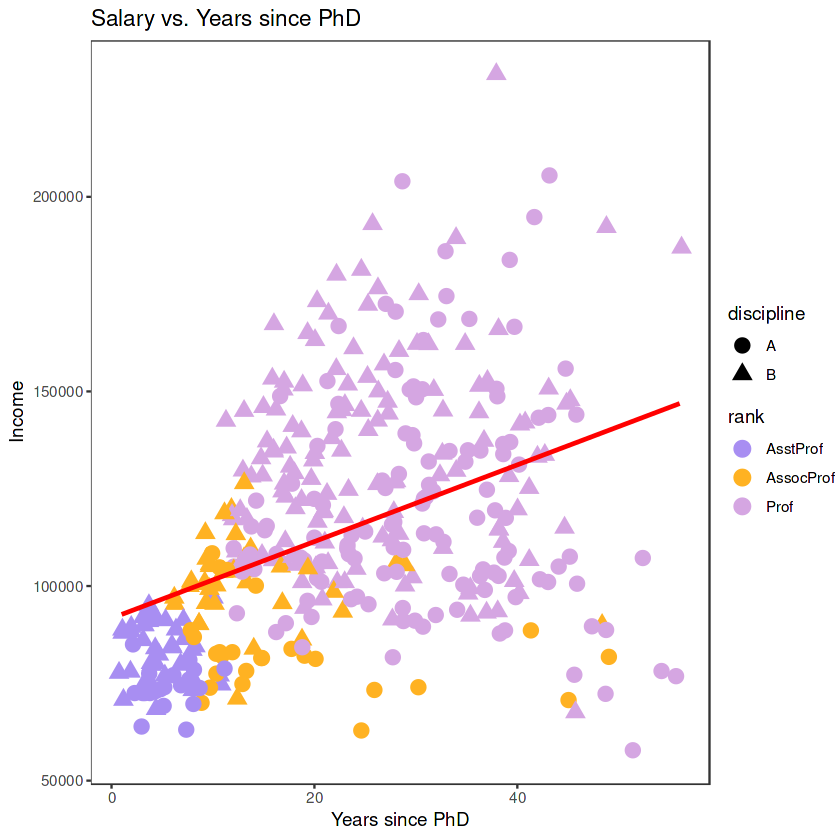

In [ ]:
# ধাপ ৫ঃ অ্যাডভান্সড কাস্টমাইজেশন
Salaries %>%
  ggplot(aes(yrs.since.phd, salary)) +
  # geom_jitter ডেটাকে কিছুটা ছড়িয়ে দেয় যাতে ওভারল্যাপিং কম হয়
  geom_jitter(aes(color = rank,
                  shape = discipline), size=4) +
  # রিগ্রেশন লাইন যোগ করা
  geom_smooth(method = lm,
              se = FALSE,
              color = "red") +
  # নিজের পছন্দমতো হেক্স কোড দিয়ে রঙ সেট করা
  scale_color_manual(values = c(
    "AsstProf" = "#A88EF2",
    "AssocProf" = "#FFB222",
    "Prof"     = "#D5A6E2"
  )) +
  theme_test() +
  labs(
    title = "Salary vs. Years since PhD",
    x = "Years since PhD",
    y = "Income",
    Color = "Position",
    Shape = "Research Area"
  )


### **৪. ইন্টারমিডিয়েট কাস্টমাইজেশন (Boxplots & Axis Styling)**

এখন আমরা র‍্যাঙ্ক অনুযায়ী বেতনের ডিস্ট্রিবিউশন দেখব এবং এক্সিস লেবেলগুলো আরও রিডেবল (Readable) করব।

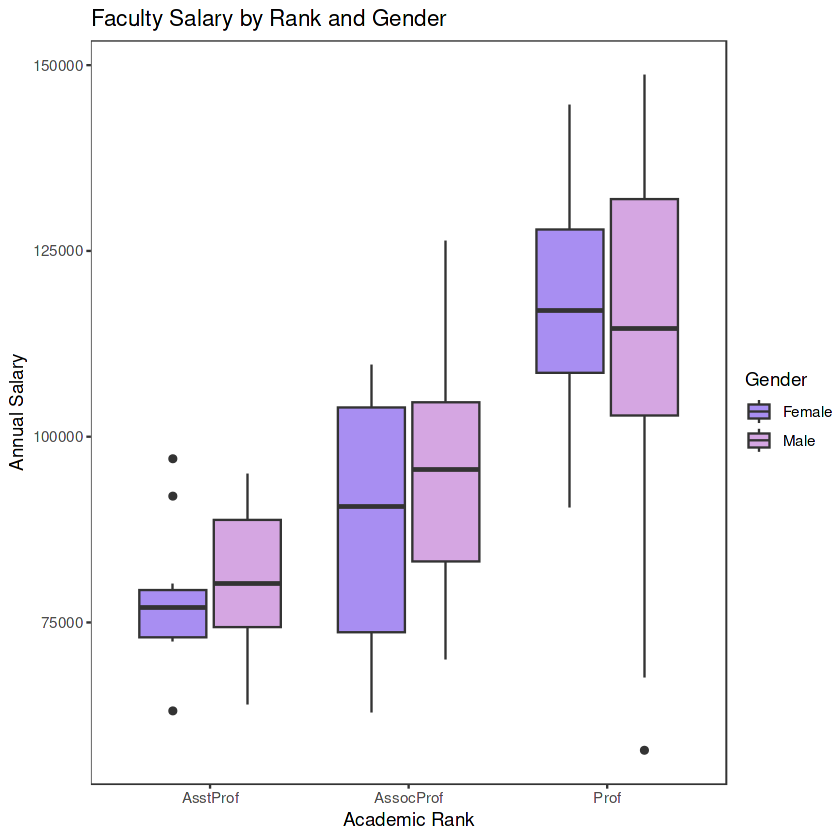

In [ ]:
# ধাপ ১ঃ ইন্টারমিডিয়েট কাস্টমাইজেশন
Salaries %>%
  filter(salary < 150000) %>% # উচ্চ বেতনের আউটলায়ার ফিল্টার করা
  ggplot(aes(rank, salary, fill = sex)) + # এখানে fill = sex যোগ করা হয়েছে ইনসাইটের জন্য
  geom_boxplot() +
  scale_fill_manual(values = c(
    "Female" = "#A88EF2",
    "Male"   = "#D5A6E2"
  )) +
  theme_test() +
labs(
    title = "Faculty Salary by Rank and Gender",
    x = "Academic Rank",
    y = "Annual Salary",
    fill = "Gender"
  )

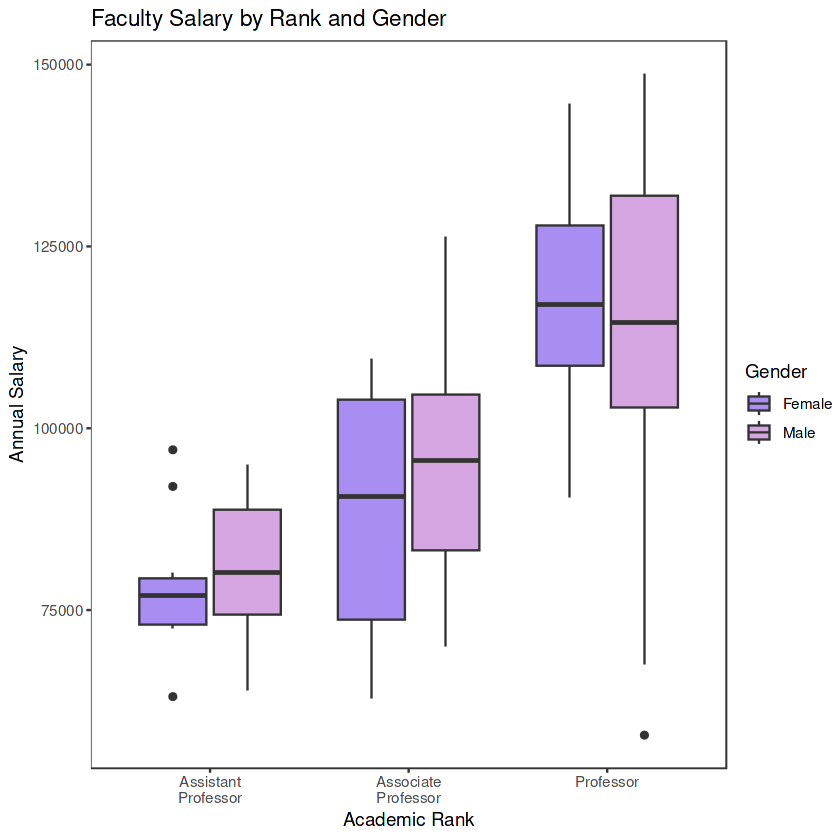

In [ ]:
# ধাপ ২ঃ ইন্টারমিডিয়েট কাস্টমাইজেশন
Salaries %>%
  filter(salary < 150000) %>% # উচ্চ বেতনের আউটলায়ার ফিল্টার করা
  ggplot(aes(rank, salary, fill = sex)) + # এখানে fill = sex যোগ করা হয়েছে ইনসাইটের জন্য
  geom_boxplot() +
  scale_fill_manual(values = c(
    "Female" = "#A88EF2",
    "Male"   = "#D5A6E2"
  )) +
  theme_test() +
  labs(
    title = "Faculty Salary by Rank and Gender",
    x = "Academic Rank",
    y = "Annual Salary",
    fill = "Gender"
  ) +

  # এক্সিস লেবেলে 'New Line' (\n) ব্যবহার করে সুন্দর করা
  scale_x_discrete(breaks = c("AsstProf", "AssocProf", "Prof"),
                   labels = c("Assistant\nProfessor",
                              "Associate\nProfessor",
                              "Professor"))

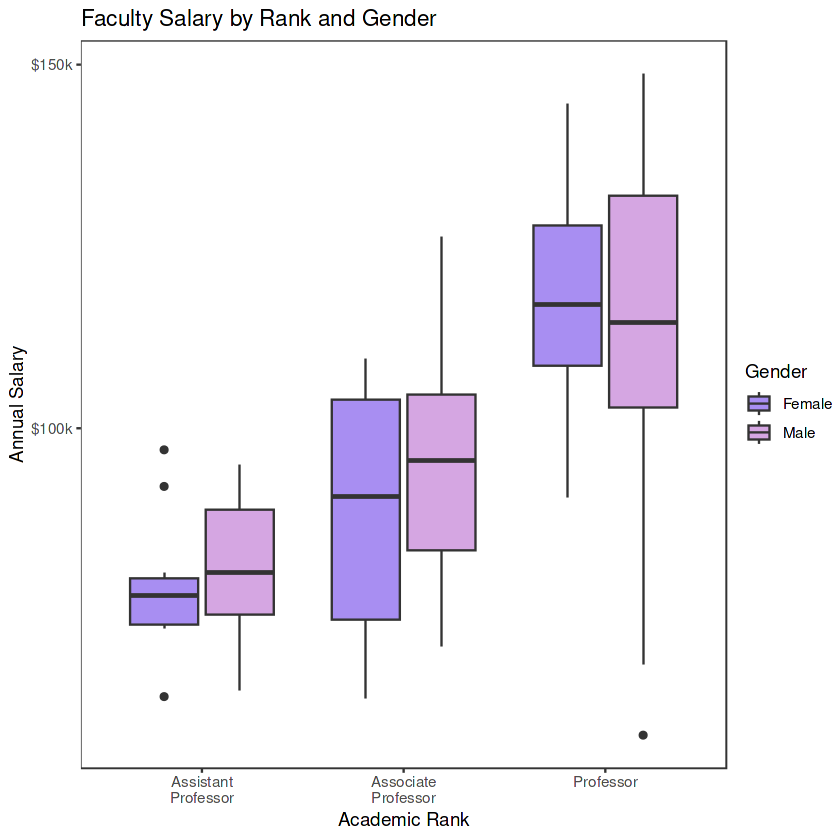

In [ ]:
# ধাপ ৩: ইন্টারমিডিয়েট কাস্টমাইজেশন
Salaries %>%
  filter(salary < 150000) %>% # উচ্চ বেতনের আউটলায়ার ফিল্টার করা
  ggplot(aes(rank, salary, fill = sex)) + # এখানে fill = sex যোগ করা হয়েছে ইনসাইটের জন্য
  geom_boxplot() +
  scale_fill_manual(values = c(
    "Female" = "#A88EF2",
    "Male"   = "#D5A6E2"
  )) +
  theme_test() +
  labs(
    title = "Faculty Salary by Rank and Gender",
    x = "Academic Rank",
    y = "Annual Salary",
    fill = "Gender"
  ) +

  # এক্সিস লেবেলে 'New Line' (\n) ব্যবহার করে সুন্দর করা
  scale_x_discrete(breaks = c("AsstProf", "AssocProf", "Prof"),
                   labels = c("Assistant\nProfessor",
                              "Associate\nProfessor",
                              "Professor")) +

  # কারেন্সি ফরম্যাটে Y-এক্সিস লেবেল সেট করা
  scale_y_continuous(breaks = c(50000, 100000, 150000, 200000),
                     labels = c("$50k", "$100k", "$150k", "$200k"))

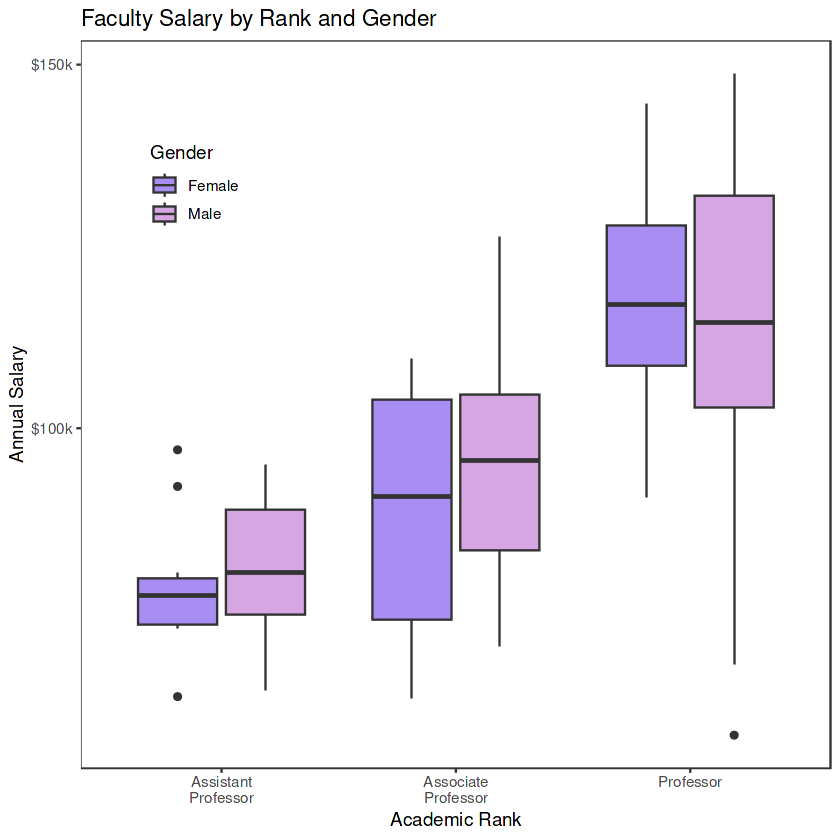

In [ ]:
# ধাপ ৪ঃ ইন্টারমিডিয়েট কাস্টমাইজেশন
Salaries %>%
  filter(salary < 150000) %>% # উচ্চ বেতনের আউটলায়ার ফিল্টার করা
  ggplot(aes(rank, salary, fill = sex)) + # এখানে fill = sex যোগ করা হয়েছে ইনসাইটের জন্য
  geom_boxplot() +
  scale_fill_manual(values = c(
    "Female" = "#A88EF2",
    "Male"   = "#D5A6E2"
  )) +
  theme_test() +
  labs(
    title = "Faculty Salary by Rank and Gender",
    x = "Academic Rank",
    y = "Annual Salary",
    fill = "Gender"
  ) +

  # এক্সিস লেবেলে 'New Line' (\n) ব্যবহার করে সুন্দর করা
  scale_x_discrete(breaks = c("AsstProf", "AssocProf", "Prof"),
                   labels = c("Assistant\nProfessor",
                              "Associate\nProfessor",
                              "Professor")) +

  # কারেন্সি ফরম্যাটে Y-এক্সিস লেবেল সেট করা
  scale_y_continuous(breaks = c(50000, 100000, 150000, 200000),
                     labels = c("$50k", "$100k", "$150k", "$200k")) +

  # লেজেন্ডকে গ্রাফের ভেতরের খালি জায়গায় নিয়ে আসা
  theme(legend.position = c(0.15, 0.80))

### **প্রো-টিপস এবং শর্টকাট:**

* **`geom_jitter()`**: যখন আপনার কাছে প্রচুর ডেটা পয়েন্ট থাকে, তখন এটি ব্যবহার করা বাধ্যতামূলক। এটি ভিজ্যুয়াল ক্লু দেয় যে কোথায় ডেটার ঘনত্ব বেশি।
* **`scale_x_discrete()`**: লম্বা লেবেলগুলোকে (`Assistant Professor`) ছোট করার জন্য `\n` ব্যবহার করা একটি দারুণ প্র্যাকটিস।
* **Legend Position**: `legend.position = c(x, y)` এর মান ০ থেকে ১ এর মধ্যে থাকে। এটি ব্যবহার করলে গ্রাফের চারপাশের জায়গা বাঁচে।

---

**দারুণ কাজ!** আপনি সফলভাবে একটি জটিল স্যালারি ডেটাসেটকে প্রফেশনাল গ্রাফে রূপান্তর করেছেন।